In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
IMG_SIZE = 48

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1))
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [3]:
CLEAN_TRAIN_DIR = "../dataset/clean/train"
CLEAN_TEST_DIR = "../dataset/clean/test"

train_dataset = datasets.ImageFolder(root=CLEAN_TRAIN_DIR, transform=train_transform)
test_dataset = datasets.ImageFolder(root=CLEAN_TEST_DIR, transform=test_transform)

print("Classes:", train_dataset.classes)
print("Class to index mapping:", train_dataset.class_to_idx)
print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Classes: ['fear', 'frustrated', 'neutral', 'sad']
Class to index mapping: {'fear': 0, 'frustrated': 1, 'neutral': 2, 'sad': 3}
Train samples: 17591
Test samples: 4518


In [4]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 275
Test batches: 71


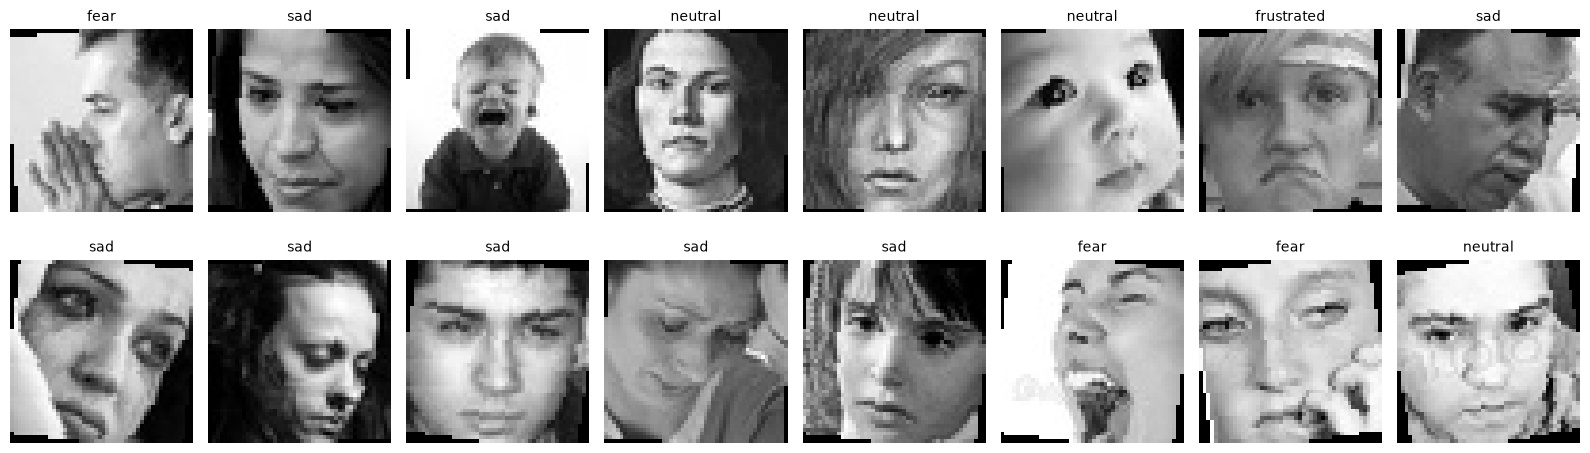

In [5]:
def imshow_batch(images, labels, classes):
    images = images.numpy()
    fig, axes = plt.subplots(2, 8, figsize=(16, 5))
    for i, ax in enumerate(axes.flat):
        if i >= len(images):
            break
        img = images[i][0] * 0.5 + 0.5
        ax.imshow(img, cmap="gray")
        ax.set_title(classes[labels[i]], fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig("../outputs/figures/04_sample_training_batch.png", dpi=150)
    plt.show()

sample_images, sample_labels = next(iter(train_loader))
imshow_batch(sample_images, sample_labels, train_dataset.classes)

In [5]:
class EmotionCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(EmotionCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.4)

        self.fc1 = nn.Linear(128 * 6 * 6, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))

        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

print("EmotionCNN class defined")

EmotionCNN class defined


In [19]:
model = EmotionCNN(num_classes=4).to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {total_params:,}")

EmotionCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (dropout): Dropout(p=0.4, inplace=False)
  (fc1): Linear(in_features=4608, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=4, bias=True)
)

Total trainable parameters: 1,274,052


In [20]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print("Loss function:", criterion)
print("Optimizer:", optimizer)
print("Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)")

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)


In [21]:
NUM_EPOCHS = 45

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
best_val_acc = 0.0

for epoch in range(NUM_EPOCHS):
    # ---- TRAINING PHASE ----
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # ---- VALIDATION PHASE ----
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    epoch_val_loss = val_running_loss / val_total
    epoch_val_acc = val_correct / val_total
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    scheduler.step(epoch_val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    # ---- BEST MODEL CHECKPOINT ----
    checkpoint_note = ""
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), '../outputs/best_model.pth')
        checkpoint_note = "  → New best model saved"

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
          f"Train Loss: {epoch_train_loss:.4f} Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} Val Acc: {epoch_val_acc:.4f} | "
          f"LR: {current_lr:.6f}{checkpoint_note}")

print(f"\nTraining complete. Best Val Acc: {best_val_acc:.4f}")

Epoch [1/45] Train Loss: 1.4194 Train Acc: 0.3089 | Val Loss: 1.3510 Val Acc: 0.3557 | LR: 0.001000  → New best model saved
Epoch [2/45] Train Loss: 1.3582 Train Acc: 0.3345 | Val Loss: 1.3343 Val Acc: 0.3887 | LR: 0.001000  → New best model saved
Epoch [3/45] Train Loss: 1.3474 Train Acc: 0.3485 | Val Loss: 1.3206 Val Acc: 0.4024 | LR: 0.001000  → New best model saved
Epoch [4/45] Train Loss: 1.3388 Train Acc: 0.3598 | Val Loss: 1.3058 Val Acc: 0.3997 | LR: 0.001000
Epoch [5/45] Train Loss: 1.3292 Train Acc: 0.3772 | Val Loss: 1.3011 Val Acc: 0.4137 | LR: 0.001000  → New best model saved
Epoch [6/45] Train Loss: 1.3184 Train Acc: 0.3833 | Val Loss: 1.2969 Val Acc: 0.4135 | LR: 0.001000
Epoch [7/45] Train Loss: 1.3121 Train Acc: 0.3921 | Val Loss: 1.2784 Val Acc: 0.4438 | LR: 0.001000  → New best model saved
Epoch [8/45] Train Loss: 1.3049 Train Acc: 0.4045 | Val Loss: 1.2623 Val Acc: 0.4511 | LR: 0.001000  → New best model saved
Epoch [9/45] Train Loss: 1.2923 Train Acc: 0.4161 | Val 

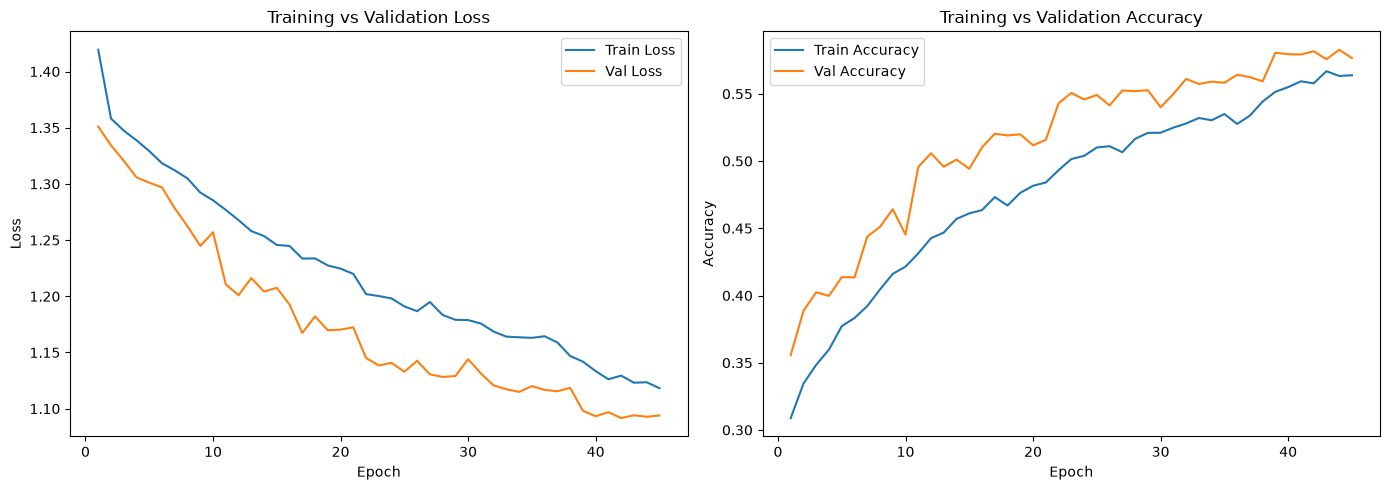

In [22]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, train_losses, label='Train Loss')
axes[0].plot(epochs_range, val_losses, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss')
axes[0].legend()

axes[1].plot(epochs_range, train_accuracies, label='Train Accuracy')
axes[1].plot(epochs_range, val_accuracies, label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/figures/05_training_curves.png', dpi=150)
plt.show()

In [7]:
eval_model = EmotionCNN(num_classes=4).to(device)
eval_model.load_state_dict(torch.load('../outputs/best_model.pth'))
eval_model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


Class order: ['fear', 'frustrated', 'neutral', 'sad']


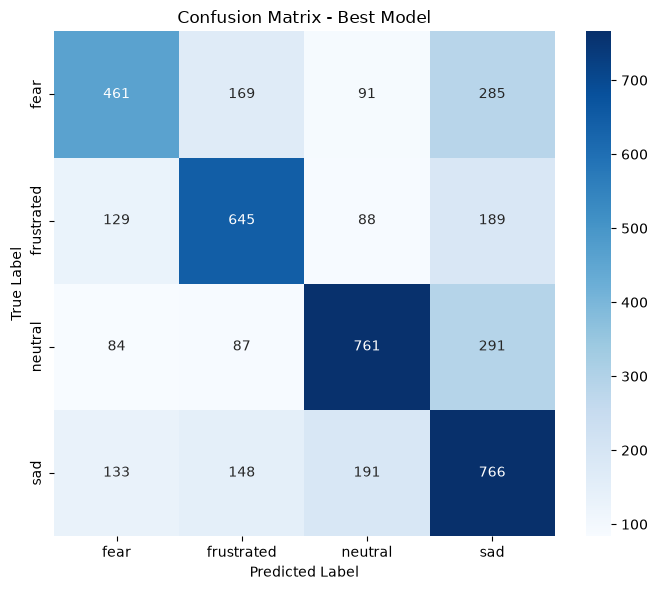


Classification Report:

              precision    recall  f1-score   support

        fear     0.5713    0.4583    0.5085      1006
  frustrated     0.6149    0.6137    0.6143      1051
     neutral     0.6729    0.6222    0.6466      1223
         sad     0.5003    0.6187    0.5533      1238

    accuracy                         0.5828      4518
   macro avg     0.5898    0.5782    0.5807      4518
weighted avg     0.5895    0.5828    0.5828      4518



In [8]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


all_preds = []
all_labels = []

eval_model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = eval_model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


class_names = train_dataset.classes
print("Class order:", class_names)


cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Best Model')
plt.tight_layout()
plt.savefig('../outputs/figures/06_confusion_matrix.png', dpi=150)
plt.show()


report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
print("\nClassification Report:\n")
print(report)

In [2]:
import torch
import torch.nn as nn
import onnxruntime as ort
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class EmotionCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(EmotionCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.4)
        self.fc1 = nn.Linear(128 * 6 * 6, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

eval_model = EmotionCNN(num_classes=4).to(device)
eval_model.load_state_dict(torch.load('../outputs/best_model.pth', map_location=device))
eval_model.eval()
print("Best checkpoint loaded.")

dummy_input = torch.randn(1, 1, 48, 48, device=device)
torch.onnx.export(
    eval_model,
    dummy_input,
    "../outputs/emotion_cnn.onnx",
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
    opset_version=12
)
print("Model exported to ONNX format: ../outputs/emotion_cnn.onnx")

ort_session = ort.InferenceSession("../outputs/emotion_cnn.onnx")
sample_image = dummy_input.cpu().numpy()
pytorch_output = eval_model(dummy_input).detach().cpu().numpy()
onnx_output = ort_session.run(None, {'input': sample_image})[0]
print("Outputs match:", np.allclose(pytorch_output, onnx_output, atol=1e-4))

Best checkpoint loaded.
Model exported to ONNX format: ../outputs/emotion_cnn.onnx
Outputs match: False


In [3]:
max_diff = np.max(np.abs(pytorch_output - onnx_output))
print(f"Max absolute difference: {max_diff}")

pytorch_class = np.argmax(pytorch_output, axis=1)
onnx_class = np.argmax(onnx_output, axis=1)
print(f"PyTorch predicted class: {pytorch_class}")
print(f"ONNX predicted class:    {onnx_class}")
print(f"Same predicted class: {pytorch_class[0] == onnx_class[0]}")

Max absolute difference: 0.0005884468555450439
PyTorch predicted class: [1]
ONNX predicted class:    [1]
Same predicted class: True
